# 03 · Блоки A (8.1) и B (8.2–8.3) — итеративная LLM-разметка

Основание: `docs/archive/dataset_design_v1.md` §8.1–8.3.

## Блок A (что покрываем)
1. **SMS Spam spam** — если уже есть результат `01_sms_spam_annotation.ipynb`, только аналитика (блок B); иначе можно дозаполнять пропуски батчами.
2. **SpamAssassin spam** — стратифицированная подвыборка по уникальному тексту (не весь корпус).
3. **Enron spam** — стратифицированный **candidate pool** (не все ~17k).
4. **Enron 419 filter** — все **уникальные** тексты из keyword-subset (объём ~731; батчами с кешем).
5. **Diagnostic ham** — Enron ham, SpamAssassin ham, SMS ham — стратифицированные подвыборки (v1 §5.2–5.4).
6. Пункт 6 блока A (переписать промпты) — **вне ноутбука**; здесь только данные для решений.

## Блок B
После накопления разметки: распределения классов, доля confidence, `core_candidate`, длины, URL, примеры low-confidence.

## Блок 8.3 — режим работы
Запускайте ноутбук **много раз**: в конфиге задайте `MAX_NEW_THIS_RUN` и `SLEEP_SEC`. Уже размеченное **никогда не перезапрашивается** — хранится в `data/interim/annotated/block_ab/cache/*.jsonl`.

## Репрезентативность без полного корпуса
- Дедупликация по нормализованному тексту.
- Страты: для email-spam — `subset` или `archive` × квантиль длины × `has_url` × грубый keyword-proxy (как в `02_enron_sa_structure_exploration.ipynb`).
- Фиксированный `RANDOM_SEED` и сохранённый файл выборки `samples/*.jsonl` — повторный запуск не меняет состав выборки.

In [17]:
# ── 1. CONFIG — правьте здесь перед каждым запуском ─────────────────────────
from __future__ import annotations

RANDOM_SEED = 42

# Размеры стратифицированных выборок (репрезентативно, без полного корпуса)
N_ENRON_SPAM_UNIQUE   = 1_200   # v1 §7.1 рекомендует 1000–1500 для candidate pool
N_SA_SPAM_UNIQUE      = 700     # меньше 1630 unique, но с покрытием страт
N_ENRON_HAM           = 420     # v1 §5.2: 300–500
N_SA_HAM              = 320     # v1 §5.3: 250–350
N_SMS_HAM             = 320     # v1 §5.4: 250–400

# Итеративный режим API
BATCH_SIZE         = 12          # записей подряд до паузы
SLEEP_SEC          = 2.5        # пауза между батчами (сек)
MAX_NEW_THIS_RUN   = 300         # максимум НОВЫХ вызовов API за один прогон ноутбука

ANNOTATION_MODEL = "openai/gpt-4o-mini"

# Какие потоки обрабатывать в этом прогоне (True = участвует в цикле разметки)
RUN_SA_SPAM     = True
RUN_ENRON_SPAM  = True
RUN_ENRON_419   = True
RUN_ENRON_HAM   = True
RUN_SA_HAM      = True
RUN_SMS_HAM     = True
RUN_SMS_SPAM_GAP = True         # дозаполнить пропуски, если есть sms_spam_annotated.jsonl от ноутбука 01

print("MAX_NEW_THIS_RUN =", MAX_NEW_THIS_RUN, "| SLEEP_SEC =", SLEEP_SEC)

MAX_NEW_THIS_RUN = 300 | SLEEP_SEC = 2.5


In [2]:
# ── 2. Setup ───────────────────────────────────────────────────────────────
import hashlib
import json
import os
import re
import time
from collections import Counter, defaultdict
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from dotenv import load_dotenv
from openai import OpenAI, APIError, RateLimitError
from tenacity import retry, stop_after_attempt, wait_exponential, retry_if_exception_type
from tqdm.auto import tqdm

def _find_v2_root() -> Path:
    candidate = Path(globals().get("__vsc_ipynb_file__",
                     globals().get("__file__", "."))).resolve()
    for p in [candidate, *candidate.parents]:
        if (p / "pyproject.toml").exists() and (p / "notebooks").exists():
            return p
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "pyproject.toml").exists() and (p / "notebooks").exists():
            return p
    raise RuntimeError("Cannot find v2/ project root")

V2_ROOT    = _find_v2_root()
RAW_DIR    = V2_ROOT / "data" / "raw" / "collected"
INTERIM    = V2_ROOT / "data" / "interim" / "annotated"
BLOCK_AB   = INTERIM / "block_ab"
SAMP_DIR   = BLOCK_AB / "samples"
CACHE_DIR  = BLOCK_AB / "cache"
OUT_FIGS   = V2_ROOT / "outputs" / "figures" / "annotation"
OUT_TABLES = V2_ROOT / "outputs" / "tables"

for d in (BLOCK_AB, SAMP_DIR, CACHE_DIR, OUT_FIGS, OUT_TABLES):
    d.mkdir(parents=True, exist_ok=True)

env_file = V2_ROOT / ".env"
if env_file.exists():
    load_dotenv(env_file)
else:
    load_dotenv()

api_key = os.environ.get("OPENROUTER_API_KEY", "")
if not api_key:
    raise EnvironmentError(
        "OPENROUTER_API_KEY not set. Add to v2/.env"
    )

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=api_key,
)
print(f"V2_ROOT={V2_ROOT}\nBLOCK_AB={BLOCK_AB}")

V2_ROOT=/Users/askar/projects/antifraud-deepfake-detection/v2
BLOCK_AB=/Users/askar/projects/antifraud-deepfake-detection/v2/data/interim/annotated/block_ab


In [3]:
# ── 3. Helpers: I/O, keys, stratified sampling ─────────────────────────────

def load_jsonl(path: Path) -> list[dict]:
    if not path.exists():
        return []
    return [json.loads(l) for l in path.read_text(encoding="utf-8").splitlines() if l.strip()]


def save_jsonl(path: Path, rows: list[dict]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        for r in rows:
            f.write(json.dumps(r, ensure_ascii=False) + "\n")


def append_cache_line(path: Path, obj: dict) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("a", encoding="utf-8") as f:
        f.write(json.dumps(obj, ensure_ascii=False) + "\n")


def ann_key(stream: str, text: str) -> str:
    norm = (text or "").strip()
    h = hashlib.sha256(f"{stream}::{norm}".encode("utf-8", errors="replace")).hexdigest()
    return h[:48]


def md5_text_key(text: str) -> str:
    """Same key as notebooks/01_sms_spam_annotation.ipynb for cache compatibility."""
    return hashlib.md5((text or "").strip().encode("utf-8", errors="replace")).hexdigest()


def load_cache_map(cache_path: Path) -> dict[str, dict]:
    m: dict[str, dict] = {}
    for line in load_jsonl(cache_path):
        k = line.get("ann_key")
        if k:
            m[k] = line
    return m


def wc(t: str) -> int:
    return len((t or "").split())


def wc_bin(n: int) -> str:
    if n < 40:
        return "short"
    if n < 200:
        return "medium"
    return "long"


def proxy_bucket_spam(text: str) -> str:
    """Crude bucket for stratification (same spirit as 02_enron_sa notebook)."""
    t = (text or "").lower()
    if any(k in t for k in ("beneficiary", "next of kin", "inheritance", "million dollar", "barrister")):
        return "p419"
    if any(k in t for k in ("verify", "password", "account", "suspended", "click here", "paypal")):
        return "pphish"
    if any(k in t for k in (".exe", "attachment", "virus", "zip")):
        return "pmalw"
    if any(k in t for k in ("unsubscribe", "free", "offer", "viagra", "discount", "casino")):
        return "ppromo"
    return "pother"


def stratified_sample_df(df: pd.DataFrame, n: int, strata_cols: list[str], seed: int) -> pd.DataFrame:
    """Approximately proportional sample of n rows (sklearn stratify on composite stratum)."""
    if len(df) <= n:
        return df.copy()
    df = df.copy().reset_index(drop=True)
    for c in strata_cols:
        if c not in df.columns:
            df[c] = "_na_"
        df[c] = df[c].fillna("_na_").astype(str)
    y = df[strata_cols].agg("|".join, axis=1)
    try:
        sample, _ = train_test_split(
            df, train_size=n, stratify=y, random_state=seed, shuffle=True,
        )
        return sample.reset_index(drop=True)
    except ValueError:
        return df.sample(n=n, random_state=seed).reset_index(drop=True)


KW_419 = (
    "beneficiary", "next of kin", "deceased", "inheritance", "million dollar",
    "barrister", "foreign account", "strictly confidential", "late client",
    "transfer of funds", "funds transfer", "oil contract", "dear friend",
    "dearest beloved", "am contacting you", "good day",
)


def is_419_candidate(text: str) -> bool:
    t = (text or "").lower()
    return any(k in t for k in KW_419)

print("Helpers OK")

Helpers OK


In [4]:
# ── 4. Build frozen samples (once) ─────────────────────────────────────────
def dedupe_records(records: list[dict], text_key: str = "text") -> list[dict]:
    seen: set[str] = set()
    out: list[dict] = []
    for r in records:
        k = ann_key("dedupe", r.get(text_key) or "")
        if k in seen:
            continue
        seen.add(k)
        out.append(r)
    return out


def ensure_sample(path: Path, builder) -> list[dict]:
    if path.exists():
        return load_jsonl(path)
    rows = builder()
    save_jsonl(path, rows)
    print(f"Created sample {path.name}  n={len(rows)}")
    return rows


enron_all = load_jsonl(RAW_DIR / "enron.jsonl")
sa_all    = load_jsonl(RAW_DIR / "spamassassin.jsonl")

enron_spam = [r for r in enron_all if r.get("label") == "spam"]
enron_ham  = [r for r in enron_all if r.get("label") == "ham"]
sa_spam    = [r for r in sa_all if r.get("label") == "spam"]
sa_ham     = [r for r in sa_all if r.get("label") == "ham"]
sms_all    = load_jsonl(RAW_DIR / "sms_spam.jsonl")
sms_ham    = [r for r in sms_all if r.get("label") == "ham"]


def build_enron_spam_sample() -> list[dict]:
    uniq = dedupe_records(enron_spam)
    rows = []
    for r in uniq:
        txt = r.get("text") or ""
        rows.append({
            **r,
            "_stratum_subset": r.get("subset", ""),
            "_stratum_wc": wc_bin(wc(txt)),
            "_stratum_url": str(bool(r.get("has_url"))),
            "_stratum_proxy": proxy_bucket_spam(txt),
        })
    df = pd.DataFrame(rows)
    picked = stratified_sample_df(
        df, N_ENRON_SPAM_UNIQUE,
        ["_stratum_subset", "_stratum_wc", "_stratum_url", "_stratum_proxy"],
        RANDOM_SEED,
    )
    return picked.drop(columns=[c for c in picked.columns if c.startswith("_stratum_")]).to_dict("records")


def build_sa_spam_sample() -> list[dict]:
    uniq = dedupe_records(sa_spam)
    rows = []
    for r in uniq:
        txt = r.get("text") or ""
        rows.append({
            **r,
            "_stratum_arch": r.get("archive", ""),
            "_stratum_wc": wc_bin(wc(txt)),
            "_stratum_url": str(bool(r.get("has_url"))),
            "_stratum_proxy": proxy_bucket_spam(txt),
        })
    df = pd.DataFrame(rows)
    picked = stratified_sample_df(
        df, N_SA_SPAM_UNIQUE,
        ["_stratum_arch", "_stratum_wc", "_stratum_url", "_stratum_proxy"],
        RANDOM_SEED + 7,
    )
    return picked.drop(columns=[c for c in picked.columns if c.startswith("_stratum_")]).to_dict("records")


def build_enron_419_sample() -> list[dict]:
    cand = [r for r in dedupe_records(enron_spam) if is_419_candidate(r.get("text", ""))]
    return cand


def build_enron_ham_sample() -> list[dict]:
    rows = []
    for r in enron_ham:
        txt = r.get("text") or ""
        rows.append({**r, "_wc": wc_bin(wc(txt))})
    df = pd.DataFrame(rows)
    picked = stratified_sample_df(df, N_ENRON_HAM, ["subset", "_wc"], RANDOM_SEED + 11)
    return picked.drop(columns=["_wc"]).to_dict("records")


def build_sa_ham_sample() -> list[dict]:
    rows = []
    for r in sa_ham:
        txt = r.get("text") or ""
        rows.append({**r, **{"_wc": wc_bin(wc(txt))}})
    df = pd.DataFrame(rows)
    picked = stratified_sample_df(df, N_SA_HAM, ["archive", "_wc"], RANDOM_SEED + 13)
    return picked.drop(columns=["_wc"]).to_dict("records")


def build_sms_ham_sample() -> list[dict]:
    rows = []
    for r in sms_ham:
        txt = r.get("text") or ""
        rows.append({**r, "_wc": wc_bin(wc(txt))})
    df = pd.DataFrame(rows)
    picked = stratified_sample_df(df, N_SMS_HAM, ["_wc"], RANDOM_SEED + 17)
    return picked.drop(columns=["_wc"]).to_dict("records")


SAMPLE_PATHS = {
    "enron_spam":  SAMP_DIR / "enron_spam_stratified.jsonl",
    "sa_spam":     SAMP_DIR / "sa_spam_stratified.jsonl",
    "enron_419":   SAMP_DIR / "enron_419_unique.jsonl",
    "enron_ham":   SAMP_DIR / "enron_ham_stratified.jsonl",
    "sa_ham":      SAMP_DIR / "sa_ham_stratified.jsonl",
    "sms_ham":     SAMP_DIR / "sms_ham_stratified.jsonl",
}

sample_enron_spam = ensure_sample(SAMPLE_PATHS["enron_spam"], build_enron_spam_sample)
sample_sa_spam    = ensure_sample(SAMPLE_PATHS["sa_spam"],    build_sa_spam_sample)
sample_enron_419  = ensure_sample(SAMPLE_PATHS["enron_419"],  build_enron_419_sample)
sample_enron_ham  = ensure_sample(SAMPLE_PATHS["enron_ham"],  build_enron_ham_sample)
sample_sa_ham     = ensure_sample(SAMPLE_PATHS["sa_ham"],     build_sa_ham_sample)
sample_sms_ham    = ensure_sample(SAMPLE_PATHS["sms_ham"],    build_sms_ham_sample)

print("Sample sizes:")
print(f"  enron_spam stratified : {len(sample_enron_spam):,}")
print(f"  sa_spam stratified    : {len(sample_sa_spam):,}")
print(f"  enron_419 unique      : {len(sample_enron_419):,}")
print(f"  enron_ham             : {len(sample_enron_ham):,}")
print(f"  sa_ham                : {len(sample_sa_ham):,}")
print(f"  sms_ham               : {len(sample_sms_ham):,}")

Created sample enron_spam_stratified.jsonl  n=1200
Created sample sa_spam_stratified.jsonl  n=700
Created sample enron_419_unique.jsonl  n=678
Created sample enron_ham_stratified.jsonl  n=420
Created sample sa_ham_stratified.jsonl  n=320
Created sample sms_ham_stratified.jsonl  n=320
Sample sizes:
  enron_spam stratified : 1,200
  sa_spam stratified    : 700
  enron_419 unique      : 678
  enron_ham             : 420
  sa_ham                : 320
  sms_ham               : 320


In [5]:
# ── 5. LLM prompts (JSON only) ─────────────────────────────────────────────

SPAM_EMAIL_CLASSES = """
Exactly one "category":
- phishing_email
- candidate_419_or_advance_fee
- promo_marketing_email
- generic_spam_nonphishing
- malware_or_attachment_lure
- unclear_other

Also set booleans: has_financial_pretence, has_credentials_request,
has_reward_or_prize, has_confidentiality_appeal, core_candidate
(core_candidate = true only if the message is a plausible human fraud email anchor
for anti-fraud research: phishing/credential theft, 419/advance-fee narrative,
or malware lure — not generic promo).

"confidence": "high" | "medium" | "low"
"""

SCAM_419_CLASSES = """
Exactly one "category":
- confirmed_advance_fee_scam
- possible_419_like
- not_419
"confidence": "high" | "medium" | "low"
"""

HAM_EMAIL_CLASSES = """
Exactly one "category":
- business_email
- personal_email
- service_or_system_email
- informational_notification_email
- mixed_or_unclear
"confidence": "high" | "medium" | "low"
"""

SMS_HAM_CLASSES = """
Exactly one "category":
- personal_everyday_sms
- coordination_or_logistics_sms
- service_notification_sms
- transactional_benign_sms
- mixed_or_unclear_sms
"confidence": "high" | "medium" | "low"
"""

SMS_SPAM_CLASSES = """
Exactly one "category":
- bank_or_account_phishing
- delivery_or_service_phishing
- lottery_or_prize
- promo_or_marketing_spam
- adult_or_misc_spam
- unclear_other
Optional booleans: is_deceptive_attack, has_financial_pretence, has_urgency,
has_action_request, has_url_or_phone_cta, core_candidate
"confidence": "high" | "medium" | "low"
"""

In [6]:
# ── 6. Message builders + API ────────────────────────────────────────────

def wrap_spam_email(r: dict, source_name: str) -> list[dict]:
    subj = (r.get("subject") or "").strip()
    body = (r.get("text") or "").strip()
    user = f"Source: {source_name} (label=spam in corpus).\n"
    user += f"Subject: {subj}\n\nBody:\n{body}"
    return [
        {"role": "system", "content": "You annotate email spam for dataset design. " + SPAM_EMAIL_CLASSES + "\nRespond with JSON only matching keys: category, confidence, has_financial_pretence, has_credentials_request, has_reward_or_prize, has_confidentiality_appeal, core_candidate."},
        {"role": "user", "content": user},
    ]


def wrap_419(r: dict) -> list[dict]:
    subj = (r.get("subject") or "").strip()
    body = (r.get("text") or "").strip()
    user = f"This email was pre-filtered with 419/advance-fee keywords (silver candidate).\nSubject: {subj}\n\nBody:\n{body}"
    return [
        {"role": "system", "content": "You verify advance-fee / 419 scam narratives. " + SCAM_419_CLASSES + "\nJSON keys: category, confidence."},
        {"role": "user", "content": user},
    ]


def wrap_ham_email(r: dict, source_name: str) -> list[dict]:
    subj = (r.get("subject") or "").strip()
    body = (r.get("text") or "").strip()
    user = f"Source: {source_name} (label=ham).\nSubject: {subj}\n\nBody:\n{body}"
    return [
        {"role": "system", "content": "You classify legitimate email style. " + HAM_EMAIL_CLASSES + "\nJSON keys: category, confidence."},
        {"role": "user", "content": user},
    ]


def wrap_sms_ham(r: dict) -> list[dict]:
    body = (r.get("text") or "").strip()
    return [
        {"role": "system", "content": "You classify legitimate SMS. " + SMS_HAM_CLASSES + "\nJSON keys: category, confidence."},
        {"role": "user", "content": f"SMS:\n{body}"},
    ]


def wrap_sms_spam(r: dict) -> list[dict]:
    body = (r.get("text") or "").strip()
    return [
        {"role": "system", "content": "You classify SMS spam scenarios. " + SMS_SPAM_CLASSES + "\nJSON keys: category, confidence, is_deceptive_attack, has_financial_pretence, has_urgency, has_action_request, has_url_or_phone_cta, core_candidate (all booleans)."},
        {"role": "user", "content": f"SMS:\n{body}"},
    ]


@retry(
    retry=retry_if_exception_type((RateLimitError, APIError)),
    wait=wait_exponential(multiplier=2, min=2, max=45),
    stop=stop_after_attempt(6),
)
def call_json(messages: list[dict]) -> dict:
    resp = client.chat.completions.create(
        model=ANNOTATION_MODEL,
        messages=messages,
        response_format={"type": "json_object"},
        temperature=0,
        max_tokens=256,
    )
    return json.loads(resp.choices[0].message.content)


def validate_spam_email_ann(d: dict) -> dict:
    ok = {"phishing_email", "candidate_419_or_advance_fee", "promo_marketing_email",
          "generic_spam_nonphishing", "malware_or_attachment_lure", "unclear_other"}
    cat = d.get("category", "unclear_other")
    if cat not in ok:
        cat = "unclear_other"
    conf = d.get("confidence", "low")
    if conf not in {"high", "medium", "low"}:
        conf = "low"
    def b(x):
        return bool(x)
    return {
        "category": cat, "confidence": conf,
        "has_financial_pretence": b(d.get("has_financial_pretence")),
        "has_credentials_request": b(d.get("has_credentials_request")),
        "has_reward_or_prize": b(d.get("has_reward_or_prize")),
        "has_confidentiality_appeal": b(d.get("has_confidentiality_appeal")),
        "core_candidate": b(d.get("core_candidate")),
    }


def validate_419_ann(d: dict) -> dict:
    ok = {"confirmed_advance_fee_scam", "possible_419_like", "not_419"}
    cat = d.get("category", "possible_419_like")
    if cat not in ok:
        cat = "possible_419_like"
    conf = d.get("confidence", "low")
    if conf not in {"high", "medium", "low"}:
        conf = "low"
    return {"category": cat, "confidence": conf}


def validate_ham_email_ann(d: dict) -> dict:
    ok = {"business_email", "personal_email", "service_or_system_email",
          "informational_notification_email", "mixed_or_unclear"}
    cat = d.get("category", "mixed_or_unclear")
    if cat not in ok:
        cat = "mixed_or_unclear"
    conf = d.get("confidence", "low")
    if conf not in {"high", "medium", "low"}:
        conf = "low"
    return {"category": cat, "confidence": conf}


def validate_sms_ham_ann(d: dict) -> dict:
    ok = {"personal_everyday_sms", "coordination_or_logistics_sms", "service_notification_sms",
          "transactional_benign_sms", "mixed_or_unclear_sms"}
    cat = d.get("category", "mixed_or_unclear_sms")
    if cat not in ok:
        cat = "mixed_or_unclear_sms"
    conf = d.get("confidence", "low")
    if conf not in {"high", "medium", "low"}:
        conf = "low"
    return {"category": cat, "confidence": conf}


def validate_sms_spam_ann(d: dict) -> dict:
    ok = {"bank_or_account_phishing", "delivery_or_service_phishing", "lottery_or_prize",
          "promo_or_marketing_spam", "adult_or_misc_spam", "unclear_other"}
    cat = d.get("category", "unclear_other")
    if cat not in ok:
        cat = "unclear_other"
    conf = d.get("confidence", "low")
    if conf not in {"high", "medium", "low"}:
        conf = "low"
    def b(x):
        return bool(x)
    return {
        "category": cat, "confidence": conf,
        "is_deceptive_attack": b(d.get("is_deceptive_attack")),
        "has_financial_pretence": b(d.get("has_financial_pretence")),
        "has_urgency": b(d.get("has_urgency")),
        "has_action_request": b(d.get("has_action_request")),
        "has_url_or_phone_cta": b(d.get("has_url_or_phone_cta")),
        "core_candidate": b(d.get("core_candidate")),
    }

print("Builders OK")

Builders OK


In [18]:
# ── 7. Generic batch runner (cache + pause + cap) ──────────────────────────

def run_stream(
    stream: str,
    records: list[dict],
    cache_path: Path,
    build_messages,
    validate_ann,
    enabled: bool,
    budget: int,
) -> int:
    """Annotate up to `budget` new records for this stream. Returns number of new API calls."""
    if not enabled:
        print(f"[skip] {stream}")
        return 0
    cache = load_cache_map(cache_path)
    pending = []
    for r in records:
        k = ann_key(stream, r.get("text", ""))
        if k not in cache:
            pending.append((k, r))
    print(f"{stream}: cached={len(cache):,} pending={len(pending):,}")
    if not pending or budget <= 0:
        return 0
    done_calls = 0
    batch_i = 0
    for k, r in tqdm(pending, desc=stream):
        if done_calls >= budget:
            break
        try:
            raw = call_json(build_messages(r))
            ann = validate_ann(raw)
        except Exception as e:
            err = str(e)[:200]
            if stream in ("sa_spam", "enron_spam"):
                ann = validate_spam_email_ann({"category": "unclear_other", "confidence": "low"})
                ann["_error"] = err
            elif stream == "enron_419":
                ann = validate_419_ann({"category": "possible_419_like", "confidence": "low"})
                ann["_error"] = err
            elif stream in ("enron_ham", "sa_ham"):
                ann = validate_ham_email_ann({"category": "mixed_or_unclear", "confidence": "low"})
                ann["_error"] = err
            elif stream == "sms_ham":
                ann = validate_sms_ham_ann({"category": "mixed_or_unclear_sms", "confidence": "low"})
                ann["_error"] = err
            else:
                ann = validate_sms_spam_ann({"category": "unclear_other", "confidence": "low"})
                ann["_error"] = err
        row = {
            "ann_key": k,
            "stream": stream,
            "annotation": ann,
            "annotation_model": ANNOTATION_MODEL,
            "annotated_at": datetime.now(timezone.utc).isoformat(),
            "raw": r,
        }
        append_cache_line(cache_path, row)
        cache[k] = row
        done_calls += 1
        batch_i += 1
        if batch_i >= BATCH_SIZE:
            batch_i = 0
            time.sleep(SLEEP_SEC)
    print(f"{stream}: +{done_calls} new annotations this run")
    return done_calls


CACHE_FILES = {
    "sa_spam":    CACHE_DIR / "sa_spam.jsonl",
    "enron_spam": CACHE_DIR / "enron_spam.jsonl",
    "enron_419":  CACHE_DIR / "enron_419.jsonl",
    "enron_ham":  CACHE_DIR / "enron_ham.jsonl",
    "sa_ham":     CACHE_DIR / "sa_ham.jsonl",
    "sms_ham":    CACHE_DIR / "sms_ham.jsonl",
    "sms_spam_gap": CACHE_DIR / "sms_spam_gap.jsonl",
}

budget_left = MAX_NEW_THIS_RUN

budget_left -= run_stream(
    "sa_spam", sample_sa_spam, CACHE_FILES["sa_spam"],
    lambda r: wrap_spam_email(r, "SpamAssassin"),
    validate_spam_email_ann, RUN_SA_SPAM, budget_left,
)

budget_left -= run_stream(
    "enron_spam", sample_enron_spam, CACHE_FILES["enron_spam"],
    lambda r: wrap_spam_email(r, "Enron-Spam"),
    validate_spam_email_ann, RUN_ENRON_SPAM, budget_left,
)

budget_left -= run_stream(
    "enron_419", sample_enron_419, CACHE_FILES["enron_419"],
    wrap_419, validate_419_ann, RUN_ENRON_419, budget_left,
)

budget_left -= run_stream(
    "enron_ham", sample_enron_ham, CACHE_FILES["enron_ham"],
    lambda r: wrap_ham_email(r, "Enron ham"),
    validate_ham_email_ann, RUN_ENRON_HAM, budget_left,
)

budget_left -= run_stream(
    "sa_ham", sample_sa_ham, CACHE_FILES["sa_ham"],
    lambda r: wrap_ham_email(r, "SpamAssassin ham"),
    validate_ham_email_ann, RUN_SA_HAM, budget_left,
)

budget_left -= run_stream(
    "sms_ham", sample_sms_ham, CACHE_FILES["sms_ham"],
    wrap_sms_ham, validate_sms_ham_ann, RUN_SMS_HAM, budget_left,
)

# SMS spam gap-fill: only rows in raw spam that are missing scenario_family in notebook-01 file
sms_ann_path = INTERIM / "sms_spam_annotated.jsonl"
if RUN_SMS_SPAM_GAP and budget_left > 0 and sms_ann_path.exists():
    existing = load_jsonl(sms_ann_path)
    have = {md5_text_key(r.get("text", "")) for r in existing if r.get("scenario_family")}
    sms_spam = [r for r in sms_all if r.get("label") == "spam"]
    missing = [r for r in sms_spam if md5_text_key(r.get("text", "")) not in have]
    print(f"sms_spam gap: {len(missing):,} missing from {sms_ann_path.name}")
    budget_left -= run_stream(
        "sms_spam_gap", missing, CACHE_FILES["sms_spam_gap"],
        wrap_sms_spam, validate_sms_spam_ann, True, budget_left,
    )
elif RUN_SMS_SPAM_GAP and not sms_ann_path.exists():
    print("sms_spam gap: no sms_spam_annotated.jsonl — run notebook 01 first or set RUN_SMS_SPAM_GAP=False")

print(f"\nRemaining budget (unused this run): {budget_left}")

sa_spam: cached=240 pending=460


sa_spam:   0%|          | 0/460 [00:00<?, ?it/s]

sa_spam: +300 new annotations this run
enron_spam: cached=0 pending=1,200
enron_419: cached=0 pending=678
enron_ham: cached=0 pending=420
sa_ham: cached=0 pending=320
sms_ham: cached=0 pending=320

Remaining budget (unused this run): 0


In [19]:
# ── 8. Block B — analytics (all completed annotations) ─────────────────────

def cache_to_df(cache_path: Path, stream: str) -> pd.DataFrame:
    rows = load_jsonl(cache_path)
    if not rows:
        return pd.DataFrame()
    out = []
    for line in rows:
        ann = line.get("annotation") or {}
        raw = line.get("raw") or {}
        txt = raw.get("text") or ""
        out.append({
            "stream": stream,
            "category": ann.get("category"),
            "confidence": ann.get("confidence"),
            "core_candidate": ann.get("core_candidate"),
            "wc": wc(txt),
            "has_url": raw.get("has_url"),
            "text_preview": txt[:120],
            **{k: ann.get(k) for k in ann if k not in ("category", "confidence", "core_candidate", "_error")},
        })
    return pd.DataFrame(out)


frames = []
pairs = [
    ("sa_spam", CACHE_FILES["sa_spam"]),
    ("enron_spam", CACHE_FILES["enron_spam"]),
    ("enron_419", CACHE_FILES["enron_419"]),
    ("enron_ham", CACHE_FILES["enron_ham"]),
    ("sa_ham", CACHE_FILES["sa_ham"]),
    ("sms_ham", CACHE_FILES["sms_ham"]),
    ("sms_spam_gap", CACHE_FILES["sms_spam_gap"]),
]
for name, path in pairs:
    df = cache_to_df(path, name)
    if len(df):
        frames.append(df)

# Merge SMS spam from notebook 01 for Block B
sms_legacy = INTERIM / "sms_spam_annotated.jsonl"
if sms_legacy.exists():
    leg = load_jsonl(sms_legacy)
    lr = []
    for r in leg:
        if r.get("label") != "spam":
            continue
        txt = r.get("text") or ""
        lr.append({
            "stream": "sms_spam_nb01",
            "category": r.get("scenario_family"),
            "confidence": r.get("annotation_confidence"),
            "core_candidate": None,
            "wc": wc(txt),
            "has_url": r.get("has_url"),
            "text_preview": txt[:120],
        })
    frames.append(pd.DataFrame(lr))

if not frames:
    print("No annotation caches yet — increase MAX_NEW_THIS_RUN and re-run cell 7.")
    all_df = pd.DataFrame()
else:
    all_df = pd.concat(frames, ignore_index=True)

if len(all_df):
    print("=== Per-stream counts ===")
    print(all_df.groupby("stream").size().to_string())
    print("\n=== Category distribution by stream ===")
    ct = pd.crosstab(all_df["stream"], all_df["category"], margins=True)
    print(ct.to_string())
    print("\n=== Confidence mix by stream ===")
    print(pd.crosstab(all_df["stream"], all_df["confidence"], normalize="index").round(3).to_string())
    if "core_candidate" in all_df.columns and all_df["core_candidate"].notna().any():
        sub = all_df[all_df["stream"].isin(["sa_spam", "enron_spam"])]
        if len(sub):
            rate = sub.groupby("stream")["core_candidate"].apply(lambda s: s.fillna(False).mean())
            print("\n=== core_candidate rate (email spam streams) ===")
            print(rate.to_string())
    print("\n=== Median word count by stream,category (spam email only) ===")
    es = all_df[all_df["stream"].isin(["enron_spam", "sa_spam"])]
    if len(es):
        print(es.groupby(["stream", "category"])["wc"].median().to_string())
    print("\n=== URL presence rate by stream ===")
    print(all_df.groupby("stream")["has_url"].apply(lambda s: pd.to_numeric(s, errors="coerce").fillna(0).astype(bool).mean()).round(3).to_string())
    print("\n=== Low-confidence samples (up to 12 per stream) ===")
    low = all_df[all_df["confidence"] == "low"]
    for s in sorted(low["stream"].unique()):
        sub = low[low["stream"] == s].head(12)
        print(f"\n--- {s} ---")
        for _, row in sub.iterrows():
            print(f"  [{row['category']}] {row['text_preview']!r}")

    all_df.to_csv(OUT_TABLES / "block_ab_annotation_long.csv", index=False)
    ct.to_csv(OUT_TABLES / "block_ab_crosstab_stream_category.csv")
    print(f"\nSaved {OUT_TABLES / 'block_ab_annotation_long.csv'}")

=== Per-stream counts ===
stream
sa_spam          540
sms_spam_nb01    642

=== Category distribution by stream ===
category       adult_or_misc_spam  bank_or_account_phishing  candidate_419_or_advance_fee  delivery_or_service_phishing  generic_spam_nonphishing  lottery_or_prize  malware_or_attachment_lure  promo_marketing_email  promo_or_marketing_spam  unclear_other   All
stream                                                                                                                                                                                                                                                              
sa_spam                         0                         0                            39                             0                        43                 0                           1                    453                        0              4   540
sms_spam_nb01                 166                         7                             0            

/var/folders/22/l60tvhln5rlbvshvwggtvlc40000gn/T/ipykernel_85407/175602980.py:77: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rate = sub.groupby("stream")["core_candidate"].apply(lambda s: s.fillna(False).mean())


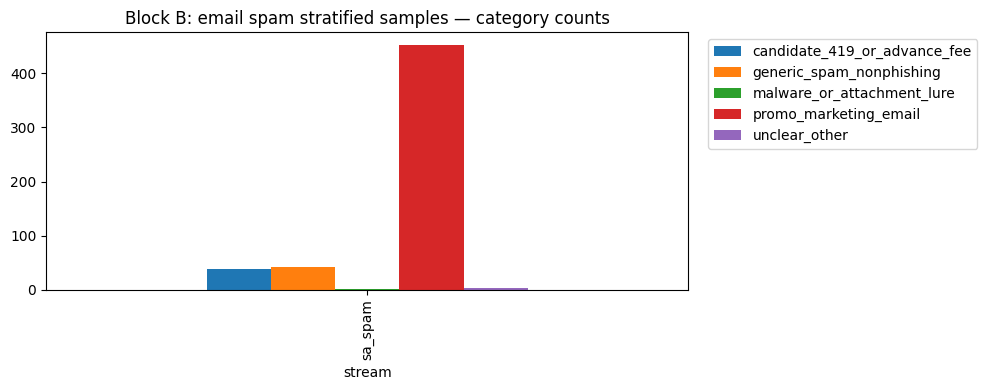

Saved /Users/askar/projects/antifraud-deepfake-detection/v2/outputs/figures/annotation/block_ab_email_spam_categories.png


In [20]:
# ── 9. Figures (Block B) ───────────────────────────────────────────────────
if len(all_df) == 0:
    print("Skip plots — no data")
else:
    spam_like = all_df[all_df["stream"].isin(["enron_spam", "sa_spam"])]
    if len(spam_like):
        fig, ax = plt.subplots(figsize=(10, 4))
        spam_like.groupby(["stream", "category"]).size().unstack(fill_value=0).plot(kind="bar", ax=ax)
        ax.set_title("Block B: email spam stratified samples — category counts")
        ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
        plt.tight_layout()
        p = OUT_FIGS / "block_ab_email_spam_categories.png"
        plt.savefig(p, dpi=150, bbox_inches="tight")
        plt.show()
        print("Saved", p)

    ham_like = all_df[all_df["stream"].isin(["enron_ham", "sa_ham", "sms_ham"])]
    if len(ham_like):
        fig, ax = plt.subplots(figsize=(10, 4))
        ham_like.groupby(["stream", "category"]).size().unstack(fill_value=0).plot(kind="bar", ax=ax)
        ax.set_title("Block B: ham diagnostic samples — category counts")
        ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
        plt.tight_layout()
        p2 = OUT_FIGS / "block_ab_ham_categories.png"
        plt.savefig(p2, dpi=150, bbox_inches="tight")
        plt.show()
        print("Saved", p2)

## Блок 8.3 — как работать дальше

1. Прогоните **ячейку 7** несколько раз с паузами (или уменьшите `MAX_NEW_THIS_RUN` для коротких сессий), пока `pending` для нужных потоков не станет 0.
2. После каждого прогона смотрите **ячейки 8–9** (блок B): распределения, `core_candidate`, low-confidence примеры.
3. Прочитайте 20–50 примеров на класс глазами; при необходимости скорректируйте промпты в ячейке 5–6 и **не удаляйте** `cache/*.jsonl` — для сравнения можно вести новый `cache_v2/` вручную.
4. Пункт A.6 (тексты промптов `legitimate_email` / `legitimate_sms` / `fraud_sms_phishing_like`) оформляйте в `docs/` отдельно на основе этих таблиц.

**Где что лежит**
- Зафиксированные выборки: `data/interim/annotated/block_ab/samples/*.jsonl`
- Накопленная разметка: `data/interim/annotated/block_ab/cache/*.jsonl`
- Экспорт аналитики: `outputs/tables/block_ab_*.csv`